In [34]:
import numpy as np
import matplotlib.pyplot as plt

# ── Load CSV (skip header) ────────────────────────────────────────────────────
data = np.loadtxt(
    "misclassified_test_samples.csv",
    delimiter=",",
    skiprows=1,
    dtype=np.uint8,
)

idx   = data[:, 0].astype(int)          # optional: original indices
truth = data[:, 1].astype(int)
pred  = data[:, 2].astype(int)
imgs  = data[:, 3:].reshape(-1, 16, 16) # shape: (N, 16, 16)

C:\Users\nikit\AppData\Local\Temp\ipykernel_56840\3746874122.py:5: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      floating point and then convert it.  (On all NumPy versions.)
  (Deprecated NumPy 1.23)
  data = np.loadtxt(


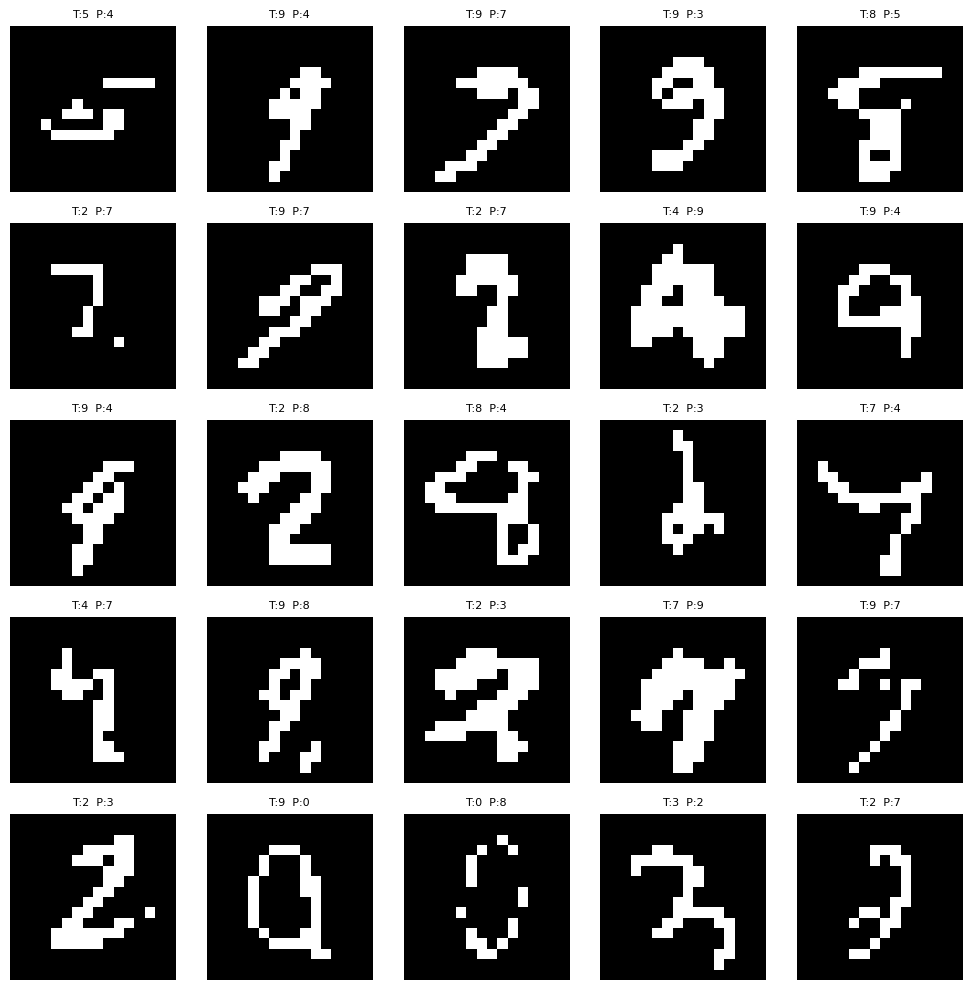

In [35]:
# ── Display first 25 errors ───────────────────────────────────────────────────
num_show = min(25, len(imgs))
rows = cols = int(np.ceil(np.sqrt(num_show)))
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))

for ax, i in zip(axes.flat, range(num_show)):
    ax.imshow(imgs[i], cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"T:{truth[i]}  P:{pred[i]}", fontsize=8)
    ax.axis("off")

for ax in axes.flat[num_show:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [36]:
times_misclassified = [0 for _ in range(10)]
for i in range(len(truth)):
    if truth[i] != pred[i]:
        times_misclassified[truth[i]] += 1

In [37]:
times_misclassified

[13, 17, 63, 13, 15, 32, 18, 8, 35, 82]